In [41]:
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [19]:
data = loadmat(r"C:\Users\sam2m\Downloads\T112_6_040_1.mat")


# 1. Flip the location data so it's a table
loc_matrix = data['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])

# 2. Extract the pressure time-series
pressure_df = pd.DataFrame(data['Wind_pressure_coefficients'])

print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")

print(loc_df.head(15))

Total Taps: 200
Total Timesteps: 32768
       X     Y  Point_No  Face_No
0   0.01  0.19       1.0      1.0
1   0.03  0.19       2.0      1.0
2   0.05  0.19       3.0      1.0
3   0.07  0.19       4.0      1.0
4   0.09  0.19       5.0      1.0
5   0.11  0.19       6.0      2.0
6   0.13  0.19       7.0      2.0
7   0.15  0.19       8.0      2.0
8   0.17  0.19       9.0      2.0
9   0.19  0.19      10.0      2.0
10  0.21  0.19      11.0      3.0
11  0.23  0.19      12.0      3.0
12  0.25  0.19      13.0      3.0
13  0.27  0.19      14.0      3.0
14  0.29  0.19      15.0      3.0


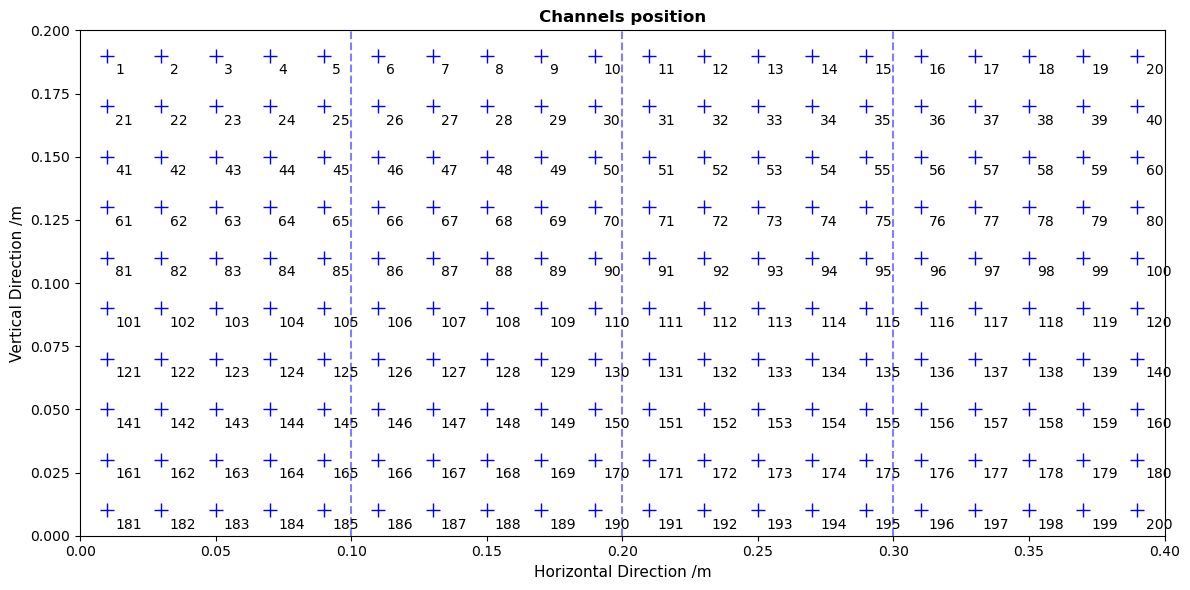

In [12]:
plt.figure(figsize=(12, 6))

# 2. Plot the taps as blue crosses
plt.scatter(loc_df['X'], loc_df['Y'], marker='+', color='blue', s=100, linewidth=1)

# 3. Iterate through the dataframe to label each tap with its 'Point_No'
for index, row in loc_df.iterrows():
    point_num = int(row['Point_No'])
    x_val = row['X']
    y_val = row['Y']
    
    # Offset the text slightly down and to the right so it doesn't overlap the cross
    plt.text(x_val + 0.003, y_val - 0.003, str(point_num), 
             color='black', fontsize=10, ha='left', va='top')

# 4. Add the vertical dashed lines separating the faces/sections (at X = 0.1, 0.2, 0.3)
for v_line in [0.1, 0.2, 0.3]:
    plt.axvline(x=v_line, color='blue', linestyle='--', alpha=0.5)

# 5. Lock the axes limits to perfectly match the original MATLAB plot
plt.xlim(0, 0.4)
plt.ylim(0, 0.2)

# 6. Add the exact titles and axis labels
plt.title("Channels position", fontweight='bold', fontsize=12)
plt.xlabel("Horizontal Direction /m", fontsize=11)
plt.ylabel("Vertical Direction /m", fontsize=11)

# Show the fully reconstructed plot
plt.tight_layout()
plt.show()

In [20]:
print(pressure_df.T.head(15))

       0         1         2         3         4         5         6      \
0   0.081778  0.108437  0.094433  0.068302  0.014652 -0.089161 -0.015373   
1   0.356692  0.334093  0.308570  0.254486  0.282317  0.275399  0.276755   
2   0.438940  0.385068  0.410581  0.397099  0.461882  0.405167  0.399931   
3   0.602296  0.556562  0.580456  0.526226  0.598775  0.529582  0.539819   
4   0.894926  0.801471  0.830834  0.730513  0.846813  0.783590  0.799193   
5   0.692290  0.655578  0.627741  0.549147  0.584303  0.554322  0.645708   
6   0.335754  0.329777  0.372942  0.359771  0.372746  0.280983  0.303622   
7   0.143343  0.143474  0.156729  0.205999  0.267616  0.209261  0.231457   
8   0.102145  0.039586  0.032281  0.064200  0.091824  0.071106  0.117369   
9  -0.122519 -0.104983 -0.118077 -0.110565 -0.096766 -0.130480 -0.112245   
10 -0.558836 -0.473980 -0.452620 -0.436406 -0.539233 -0.591605 -0.584273   
11 -0.624054 -0.536170 -0.504705 -0.510144 -0.569312 -0.603103 -0.624262   
12 -0.664834

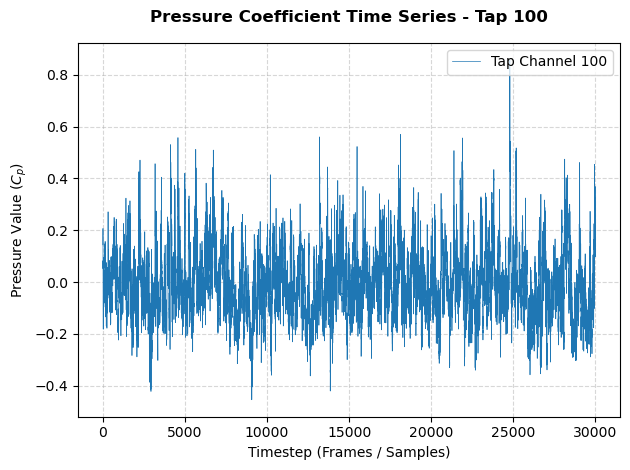

In [27]:
def get_timeseries_plot(pressure_df, tap_no, time_a, time_b):
    tap_idx = int(tap_no)
    start_idx = int(time_a)
    end_idx = int(time_b)


    pressure_tap_no = pressure_df[tap_idx]

    sliced_pressure = pressure_tap_no.iloc[start_idx: end_idx]

    plt.plot(
        sliced_pressure.index, 
        sliced_pressure.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

get_timeseries_plot(pressure_df, 100, 1, 30000)

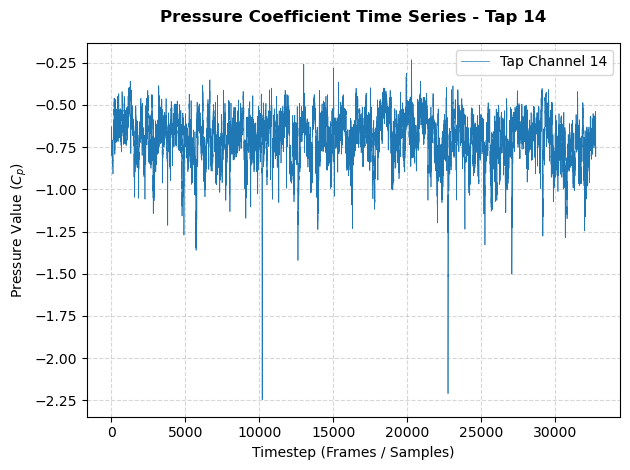

In [ ]:
def view_all_steps(pressure_df, tap_no):
    tap_idx = int(tap_no)

    pressure_at_tap = pressure_df[tap_idx]


    plt.plot(
        pressure_at_tap.index, 
        pressure_at_tap.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    
    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

view_all_steps(pressure_df, 14)



In [34]:
min_val = pressure_df[14].idxmin()
print(min_val)

10201


In [35]:
mean_cp_series = pressure_df.mean(axis = 0)
mean_cp_df = mean_cp_series.reset_index()
mean_cp_df.columns = ['Tap no.', 'mean_cp']

print(mean_cp_df)

     Tap no.   mean_cp
0          0  0.002403
1          1  0.212595
2          2  0.304919
3          3  0.404906
4          4  0.615339
..       ...       ...
195      195 -0.618636
196      196 -0.615098
197      197 -0.593501
198      198 -0.561246
199      199 -0.536454

[200 rows x 2 columns]


In [ ]:
all_means = mean_cp_df['mean_cp'].values
num_taps = len(loc_df)
matched_means = all_means[:num_taps]

# 4. Paste it directly into the coordinate DataFrame
loc_df['mean_cp'] = matched_means

print(f"Successfully mapped {len(matched_means)} mean Cp values to the coordinates.")
#print(mean_cp_df)
print(loc_df)


Successfully mapped 200 mean Cp values to the coordinates.
     Tap no.   mean_cp
0          0  0.002403
1          1  0.212595
2          2  0.304919
3          3  0.404906
4          4  0.615339
..       ...       ...
195      195 -0.618636
196      196 -0.615098
197      197 -0.593501
198      198 -0.561246
199      199 -0.536454

[200 rows x 2 columns]
        X     Y  Point_No  Face_No   mean_cp
0    0.01  0.19       1.0      1.0  0.002403
1    0.03  0.19       2.0      1.0  0.212595
2    0.05  0.19       3.0      1.0  0.304919
3    0.07  0.19       4.0      1.0  0.404906
4    0.09  0.19       5.0      1.0  0.615339
..    ...   ...       ...      ...       ...
195  0.31  0.01     196.0      4.0 -0.618636
196  0.33  0.01     197.0      4.0 -0.615098
197  0.35  0.01     198.0      4.0 -0.593501
198  0.37  0.01     199.0      4.0 -0.561246
199  0.39  0.01     200.0      4.0 -0.536454

[200 rows x 5 columns]


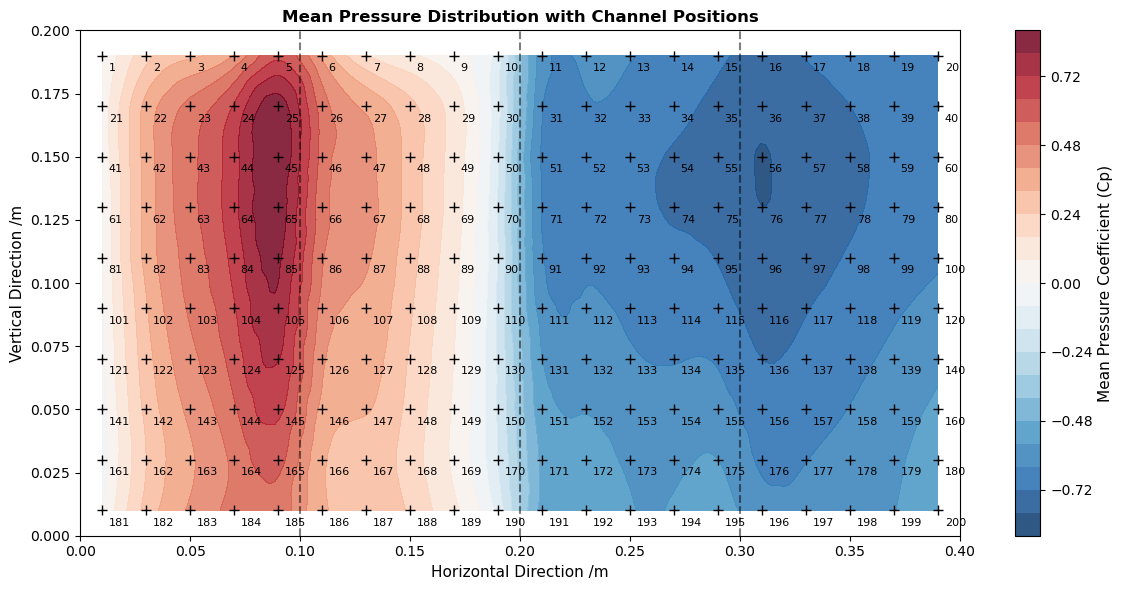

In [45]:
grid_x, grid_y = np.mgrid[0:0.4:200j, 0:0.2:100j]

# 2. Interpolate the scattered pressure data onto our new dense grid
# Change 'Mean_Cp' to whatever your actual pressure column is named!
grid_z = griddata((loc_df['X'], loc_df['Y']), loc_df['mean_cp'], (grid_x, grid_y), method='cubic')

# 3. Set up the figure
plt.figure(figsize=(12, 6))

# 4. Plot the smooth color contour map
# levels=20 gives 20 smooth color bands. 'RdBu_r' is the classic Red (high) / Blue (low) aerodynamic map
contour = plt.contourf(grid_x, grid_y, grid_z, levels=20, cmap='RdBu_r', alpha=0.85)

# Add a colorbar legend to the right side
cbar = plt.colorbar(contour)
cbar.set_label('Mean Pressure Coefficient (Cp)', fontsize=11)

# 5. Overlay the original tap locations as black crosses so they stand out against the color
plt.scatter(loc_df['X'], loc_df['Y'], marker='+', color='black', s=60, linewidth=1)

# Overlay the tap numbers (Made slightly smaller so it doesn't clutter the colors)
for index, row in loc_df.iterrows():
    plt.text(row['X'] + 0.003, row['Y'] - 0.003, str(int(row['Point_No'])), 
             color='black', fontsize=8, ha='left', va='top')

# 6. Add the vertical dashed lines back
for v_line in [0.1, 0.2, 0.3]:
    plt.axvline(x=v_line, color='black', linestyle='--', alpha=0.5)

# 7. Lock the axes limits perfectly to the original geometry
plt.xlim(0, 0.4)
plt.ylim(0, 0.2)

# 8. Add Titles and Labels
plt.title("Mean Pressure Distribution with Channel Positions", fontweight='bold', fontsize=12)
plt.xlabel("Horizontal Direction /m", fontsize=11)
plt.ylabel("Vertical Direction /m", fontsize=11)

# Show the plot
plt.tight_layout()
plt.show()  